In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib



In [46]:
df = pd.read_csv('data_cleaned.csv')

In [ ]:
features = [ 'valence','energy', 'popularity']

In [48]:
X = df[features]
y = df['mood']

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
print(f"Eğitim seti: {X_train.shape[0]} şarkı")
print(f"Test seti:   {X_test.shape[0]} şarkı")

Eğitim seti: 91199 şarkı
Test seti:   22800 şarkı


In [51]:
model = RandomForestClassifier(
    n_estimators=100,   
    random_state=42,
    n_jobs=-1          
)

model.fit(X_train, y_train)
print("Model eğitildi!")

Model eğitildi!


In [52]:
y_pred = model.predict(X_test)

print("=== Model Başarı Raporu ===\n")
print(classification_report(y_test, y_pred))

=== Model Başarı Raporu ===

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00      4754
        calm       1.00      1.00      1.00      2031
       happy       1.00      1.00      1.00      5860
         sad       1.00      1.00      1.00     10155

    accuracy                           1.00     22800
   macro avg       1.00      1.00      1.00     22800
weighted avg       1.00      1.00      1.00     22800



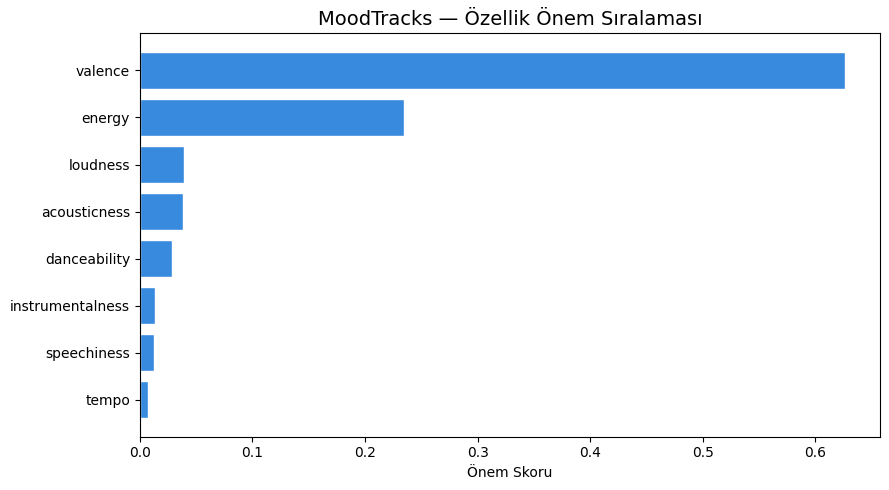

In [53]:
importance = pd.DataFrame({
    'özellik': features,
    'önem': model.feature_importances_
}).sort_values('önem', ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.barh(importance['özellik'], importance['önem'],
                color='#378ADD', edgecolor='white')

plt.title('MoodTracks — Özellik Önem Sıralaması', fontsize=14)
plt.xlabel('Önem Skoru')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [54]:
def mood_onerileri(mood, genre=None, n=10):
    
    emoji = {'happy': '😊', 'sad': '😢', 'angry': '😡', 'calm': '😌'}
    
    filtered = df[df['mood'] == mood]
    
    if genre:
        filtered = filtered[filtered['track_genre'] == genre]
    
    # Aynı şarkı tekrarını önle
    filtered = filtered.drop_duplicates(subset=['track_name', 'artists'])
    
    recommended = filtered.sort_values('popularity', ascending=False).head(n)
    
    print(f"\n{emoji[mood]} '{mood.upper()}' moduna göre öneriler:\n")
    print(f"{'#':<4} {'Şarkı':<40} {'Sanatçı':<30} {'Tür':<20} {'Popülerlik'}")
    print("-" * 105)
    
    for i, (_, row) in enumerate(recommended.iterrows(), 1):
        sarki = row['track_name'][:38]
        artist = row['artists'][:28]
        genre_name = row['track_genre'][:18]
        print(f"{i:<4} {sarki:<40} {artist:<30} {genre_name:<20} {row['popularity']:.0f}")

# Test et
mood_onerileri(mood='happy')
mood_onerileri(mood='angry')


😊 'HAPPY' moduna göre öneriler:

#    Şarkı                                    Sanatçı                        Tür                  Popülerlik
---------------------------------------------------------------------------------------------------------
1    La Bachata                               Manuel Turizo                  latin                98
2    I Ain't Worried                          OneRepublic                    piano                96
3    As It Was                                Harry Styles                   pop                  95
4    CUFF IT                                  Beyoncé                        dance                93
5    Calm Down (with Selena Gomez)            Rema;Selena Gomez              pop                  92
6    Super Freaky Girl                        Nicki Minaj                    dance                92
7    Vegas (From the Original Motion Pictur   Doja Cat                       dance                90
8    Ferrari                                

In [55]:
print(sorted(df['track_genre'].unique().tolist()))

['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk', 'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove', 'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle', 'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian', 'indie', 'indie-pop', 'industrial', 'iranian', 'j-dance', 'j-idol', 'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino', 'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb', 'new-age', 'opera', 'pagode', 'party', 'piano', 'pop', 'pop-film', 'power-pop', 'progressive-house', 'psych-rock', 'punk', 'punk-rock', 'r-n-b', 'reggae', 'reggaeton', 'rock',

In [56]:
joblib.dump(model, "moodtracks_model.pkl")
print("Model kaydedildi: moodtracks_model.pkl")

Model kaydedildi: moodtracks_model.pkl
